In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from scipy.stats import chi2_contingency
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression

In [2]:
load_dotenv("../.env")
data_path = os.getenv("Data_path_clean")

In [3]:
df=pd.read_csv(data_path)
df.head()

,CustomerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer,42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.columns

Index(['CustomerID', 'Gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'Tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [5]:
df.dtypes

CustomerID           object
Gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
Tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

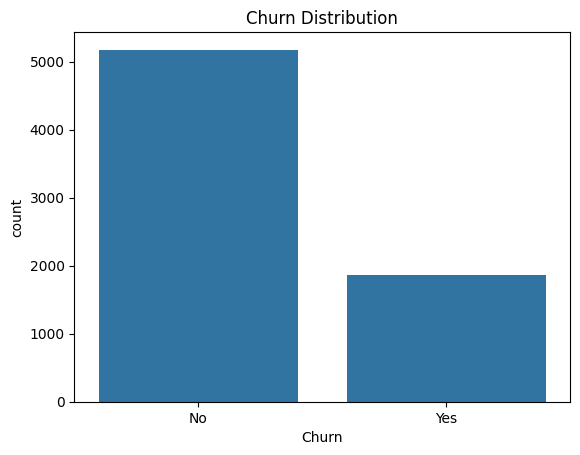

In [6]:
sns.countplot(data=df, x='Churn')
plt.title("Churn Distribution")
plt.show()

In [7]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

C:\Users\hunnu\AppData\Local\Temp\ipykernel_32492\3334698871.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2,2].set_xticklabels(axes[2,2].get_xticklabels(), rotation=20, ha='right')


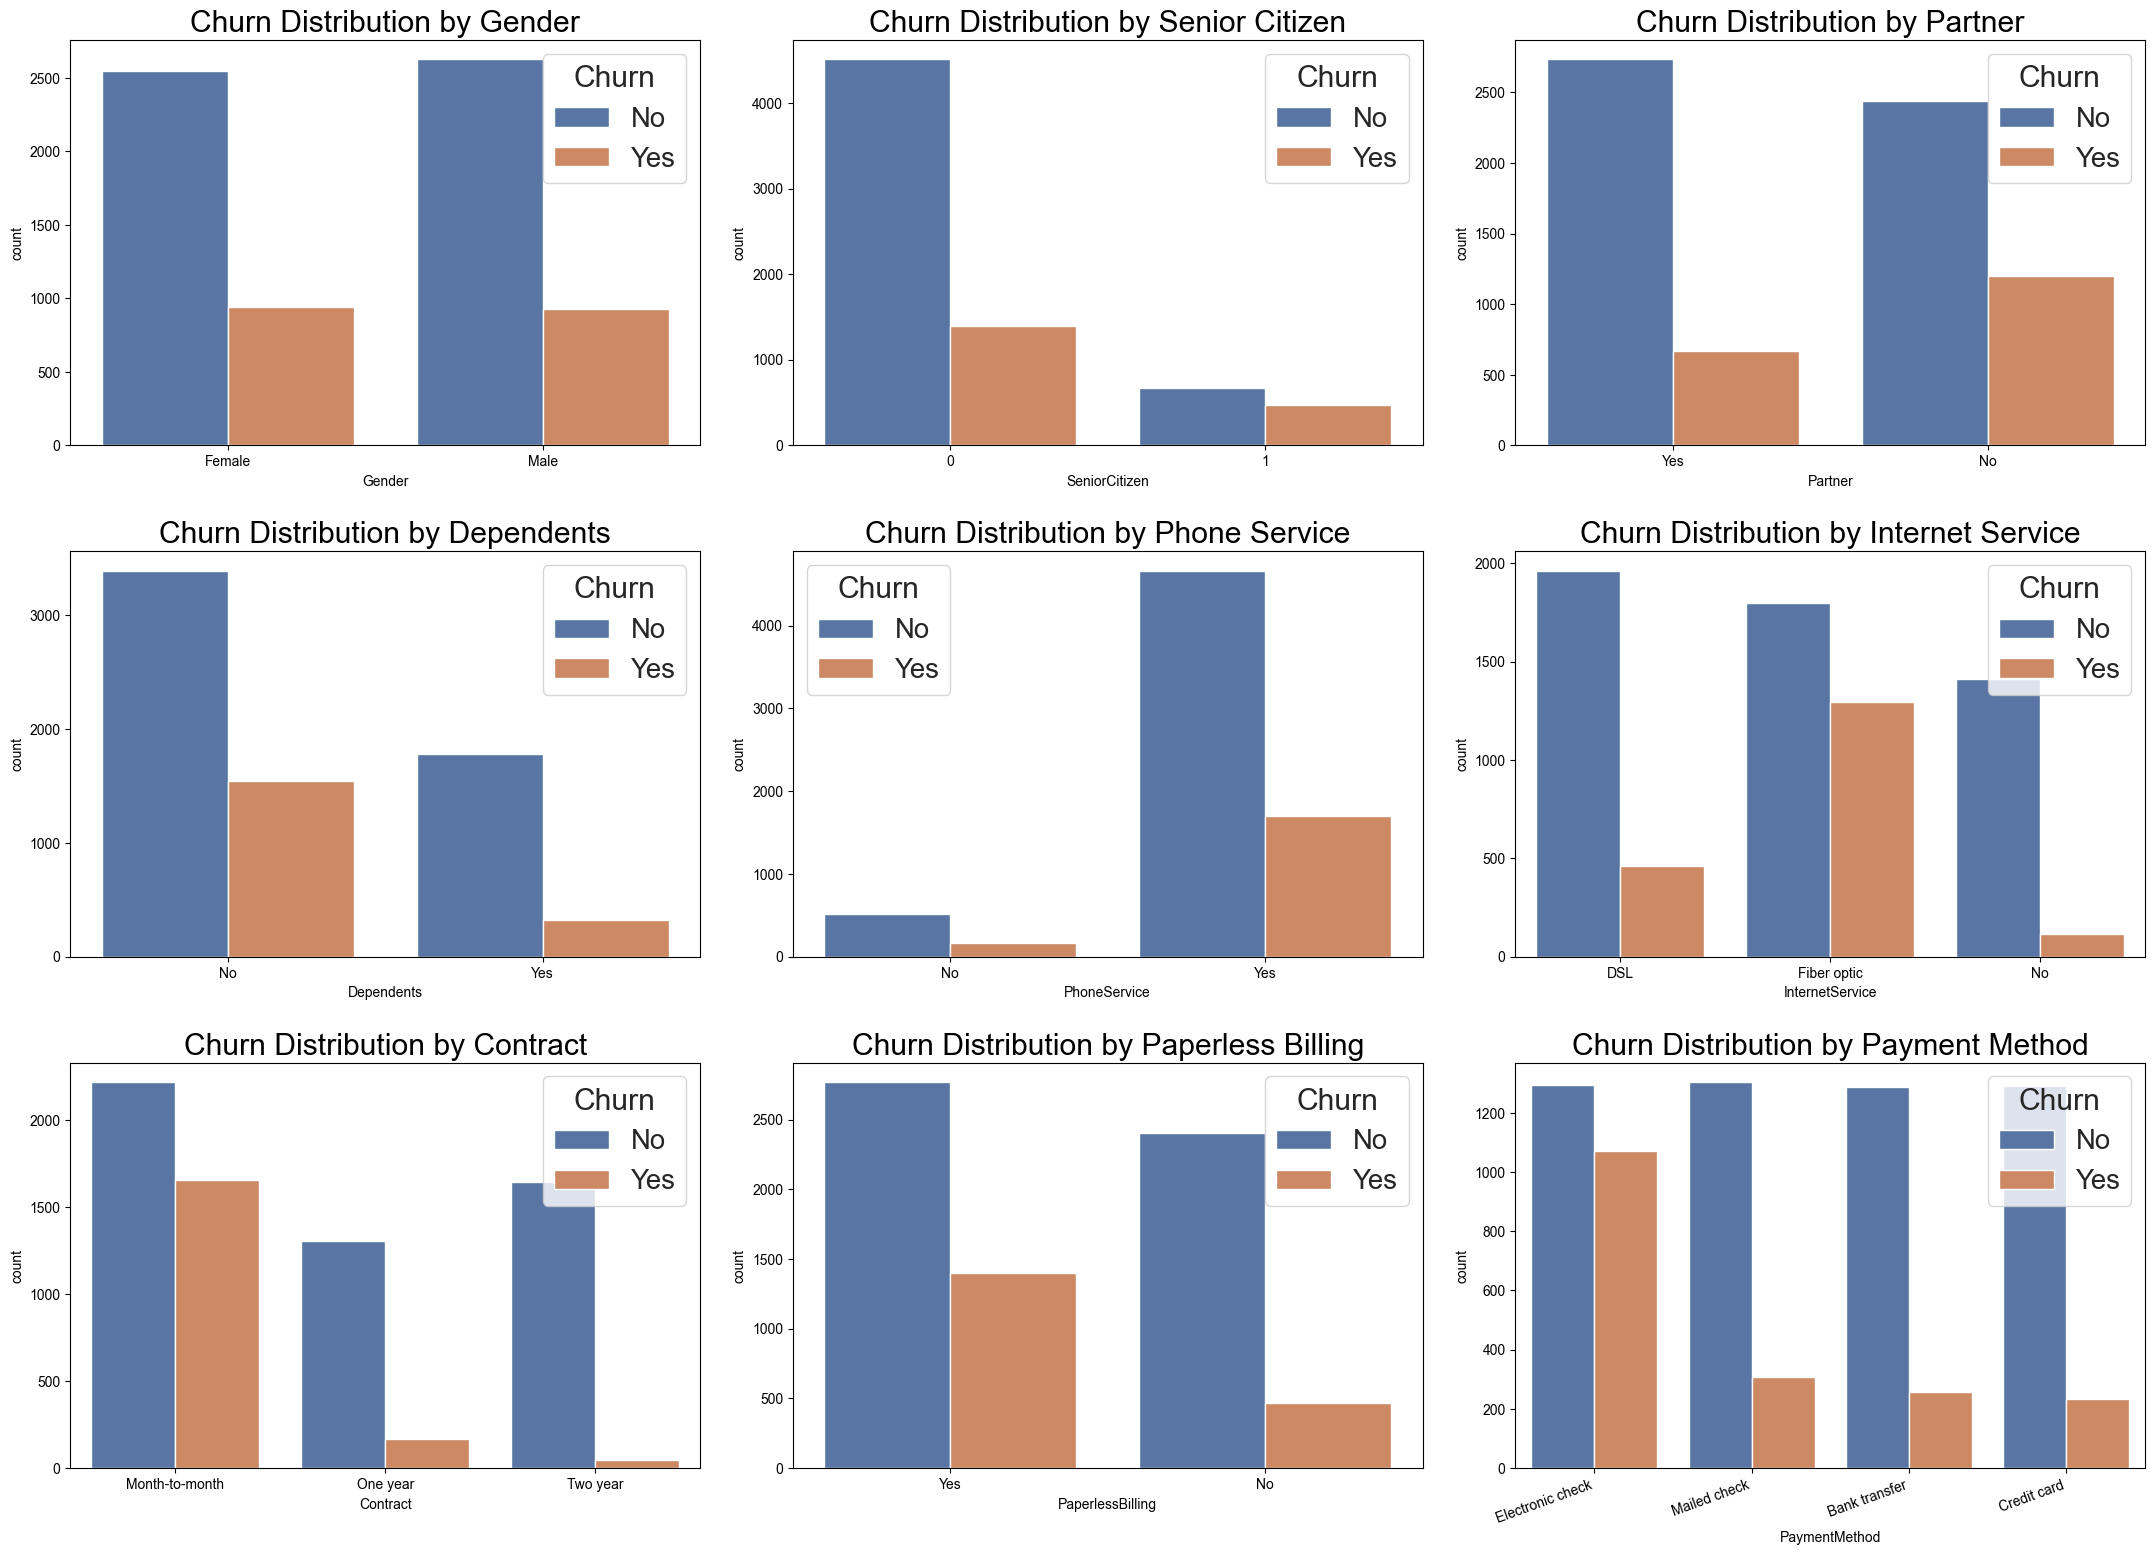

In [8]:
fig, axes = plt.subplots(3,3, figsize=(22, 16))
sns.set_theme(style="white",font_scale=1.8)

axes[0,0].set_title('Churn Distribution by Gender')
sns.countplot(data=df, x='Gender', hue='Churn', ax=axes[0,0])
axes[0,1].set_title('Churn Distribution by Senior Citizen')
sns.countplot(data=df, x='SeniorCitizen', hue='Churn', ax=axes[0,1])
axes[0,2].set_title('Churn Distribution by Partner')
sns.countplot(data=df, x='Partner', hue='Churn', ax=axes[0,2])
axes[1,0].set_title('Churn Distribution by Dependents')
sns.countplot(data=df, x='Dependents', hue='Churn', ax=axes[1,0])
axes[1,1].set_title('Churn Distribution by Phone Service')
sns.countplot(data=df, x='PhoneService', hue='Churn', ax=axes[1,1])
axes[1,2].set_title('Churn Distribution by Internet Service')
sns.countplot(data=df, x='InternetService', hue='Churn', ax=axes[1,2])
axes[2,0].set_title('Churn Distribution by Contract')
sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[2,0])
axes[2,1].set_title('Churn Distribution by Paperless Billing')
sns.countplot(data=df, x='PaperlessBilling', hue='Churn', ax=axes[2,1])
axes[2,2].set_title('Churn Distribution by Payment Method')
sns.countplot(data=df, x='PaymentMethod', hue='Churn', ax=axes[2,2])
sns.move_legend(axes[2,0], "upper right")
axes[2,2].set_xticklabels(axes[2,2].get_xticklabels(), rotation=20, ha='right')

plt.tight_layout()
plt.show()

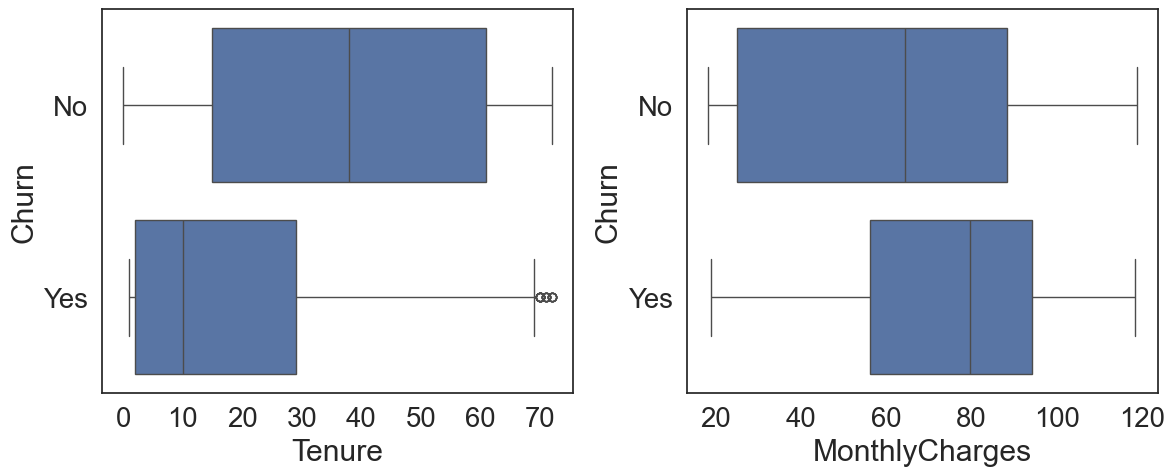

In [9]:
fig, axes = plt.subplots(1,2, figsize=(12, 5))
sns.set_theme(style="white",font_scale=1.2)
sns.boxplot(data=df, x='Tenure', y='Churn',ax=axes[0])
sns.boxplot(data=df, x='MonthlyCharges', y='Churn',ax=axes[1])

plt.tight_layout()
plt.show()

In [10]:
# Chi Sq Test
target_col = 'Churn'
exclude_cols = ['customerid', 'tenure', 'monthlycharges', 'totalcharges', target_col.lower()]
cat_cols = [c for c in df.columns if c.lower() not in exclude_cols]
results = []

for col in cat_cols:
    contingency_table = pd.crosstab(df[col], df[target_col])
    chi2, p_val, dof, _ = chi2_contingency(contingency_table)
    results.append({
        'Feature': col,
        'Chi2 Statistic': round(chi2, 4),
        'p-value': round(p_val, 6),
        'Significant (p < 0.05)': p_val < 0.05})

results_df = pd.DataFrame(results).sort_values(by='p-value')
results_df

,Feature,Chi2 Statistic,p-value,Significant (p < 0.05)
1,SeniorCitizen,159.4263,0.000000,True
2,Partner,158.7334,0.000000,True
3,Dependents,189.1292,0.000000,True
7,OnlineSecurity,205.6331,0.000000,True
6,InternetService,732.3096,0.000000,True
10,TechSupport,190.1668,0.000000,True
9,DeviceProtection,30.5134,0.000000,True
8,OnlineBackup,47.2609,0.000000,True
12,StreamingMovies,26.2513,0.000000,True
13,Contract,1184.5966,0.000000,True


In [11]:
# Multicolinearity
num_df = df[['Tenure', 'MonthlyCharges', 'TotalCharges']]
print(num_df.corr())
print()
for i, col in enumerate(num_df.columns):
    vif = variance_inflation_factor(num_df.values, i)
    print(col, 'VIF =', round(vif, 2))

                  Tenure  MonthlyCharges  TotalCharges
Tenure          1.000000        0.247900      0.826178
MonthlyCharges  0.247900        1.000000      0.651174
TotalCharges    0.826178        0.651174      1.000000

Tenure VIF = 5.84
MonthlyCharges VIF = 3.22
TotalCharges VIF = 9.51


In [12]:
# Cramers V Test
def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return (phi2 / min(k - 1, r - 1)) ** 0.5

target_col = 'Churn'
exclude_cols = ['customerid', 'tenure', 'monthlycharges', 'totalcharges', target_col.lower()]
cat_cols = [c for c in df.columns if c.lower() not in exclude_cols]

results = []
for col in cat_cols:
    ct = pd.crosstab(df[col], df[target_col])
    chi2, p_val, dof, _ = chi2_contingency(ct)
    v = cramers_v(ct)
    results.append({
        'Feature': col,
        'p-value': round(p_val, 6),
        'Significant': p_val < 0.05,
        "Cramer's V": round(v, 3)
    })

cat_results = pd.DataFrame(results).sort_values("Cramer's V", ascending=False)
print(cat_results)

             Feature   p-value  Significant  Cramer's V
13          Contract  0.000000         True       0.410
6    InternetService  0.000000         True       0.322
15     PaymentMethod  0.000000         True       0.303
14  PaperlessBilling  0.000000         True       0.191
7     OnlineSecurity  0.000000         True       0.171
10       TechSupport  0.000000         True       0.164
3         Dependents  0.000000         True       0.164
1      SeniorCitizen  0.000000         True       0.150
2            Partner  0.000000         True       0.150
8       OnlineBackup  0.000000         True       0.082
9   DeviceProtection  0.000000         True       0.066
11       StreamingTV  0.000000         True       0.063
12   StreamingMovies  0.000000         True       0.061
5      MultipleLines  0.000843         True       0.040
4       PhoneService  0.338783        False       0.011
0             Gender  0.486579        False       0.008


In [13]:
x = df.drop(columns=['CustomerID','Churn'])
y = df['Churn'].map({'Yes': 1, 'No': 0})
x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=0.2,random_state=42,stratify=y)

print('Train shape:', x_train.shape)
print('Test shape :', x_test.shape)

Train shape: (5634, 19)
Test shape : (1409, 19)


In [14]:
X_train_base = x_train.copy()
X_test_base = x_test.copy()

In [15]:
X_train_ft_engg = X_train_base.copy()
X_test_ft_engg = X_test_base.copy()

##### FT ENGG

In [16]:
opt_service_cols = ['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']

X_train_ft_engg['TotalServices'] = (X_train_ft_engg[opt_service_cols] == 'Yes').sum(axis=1)
X_test_ft_engg['TotalServices'] = (X_test_ft_engg[opt_service_cols] == 'Yes').sum(axis=1)

In [17]:
X_train_ft_engg['IsNewCustomer'] = (X_train_ft_engg['Tenure'] <= 12).astype(int)
X_test_ft_engg['IsNewCustomer'] = (X_test_ft_engg['Tenure'] <= 12).astype(int)

X_train_ft_engg['IsLongTermCustomer'] = (X_train_ft_engg['Tenure'] >= 48).astype(int)
X_test_ft_engg['IsLongTermCustomer'] = (X_test_ft_engg['Tenure'] >= 48).astype(int)

In [18]:
X_train_ft_engg['IsMonthToMonth'] = (X_train_ft_engg['Contract'] == 'Month-to-month').astype(int)
X_test_ft_engg['IsMonthToMonth'] = (X_test_ft_engg['Contract'] == 'Month-to-month').astype(int)

In [19]:
X_train_ft_engg['UseElecCheck'] = (X_train_ft_engg['PaymentMethod'] == 'Electronic check').astype(int)
X_test_ft_engg['UseElecCheck'] = (X_test_ft_engg['PaymentMethod'] == 'Electronic check').astype(int)

In [20]:
X_train_ft_engg['HasSecuritySupport'] = ((X_train_ft_engg['OnlineSecurity'] == 'Yes') | (X_train_ft_engg['TechSupport'] == 'Yes')).astype(int)
X_test_ft_engg['HasSecuritySupport'] = ((X_test_ft_engg['OnlineSecurity'] == 'Yes') | (X_test_ft_engg['TechSupport'] == 'Yes')).astype(int)

In [21]:
avg_monthly_spend_check = X_train_ft_engg['TotalCharges'] / X_train_ft_engg['Tenure'].replace(0, 1)
check_corr = pd.concat([avg_monthly_spend_check.rename('AvgMonthlySpend'), X_train_ft_engg['MonthlyCharges']],axis=1).corr()
check_corr

,AvgMonthlySpend,MonthlyCharges
AvgMonthlySpend,1.000000,0.994646
MonthlyCharges,0.994646,1.000000


In [22]:
threshold = X_train_ft_engg['MonthlyCharges'].quantile(0.75)
X_train_ft_engg['HighMonthlyCharge'] = (X_train_ft_engg['MonthlyCharges'] >= threshold).astype(int)
X_test_ft_engg['HighMonthlyCharge'] = (X_test_ft_engg['MonthlyCharges'] >= threshold).astype(int)

In [23]:
print(X_train_ft_engg.shape[1])
print(X_train_ft_engg.columns)

26
Index(['Gender', 'SeniorCitizen', 'Partner', 'Dependents', 'Tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'TotalServices', 'IsNewCustomer',
       'IsLongTermCustomer', 'IsMonthToMonth', 'UseElecCheck',
       'HasSecuritySupport', 'HighMonthlyCharge'],
      dtype='object')


##### FT ANALYSIS

In [24]:
numeric_col_train = X_train_ft_engg[['Tenure', 'MonthlyCharges', 'TotalCharges']].copy()
numeric_col_train['Churn'] = y_train.values
numeric_col_train.corr()

,Tenure,MonthlyCharges,TotalCharges,Churn
Tenure,1.000000,0.256700,0.829698,-0.345593
MonthlyCharges,0.256700,1.000000,0.654117,0.198040
TotalCharges,0.829698,0.654117,1.000000,-0.193761
Churn,-0.345593,0.198040,-0.193761,1.000000


In [25]:
# Cramers for train
target_col = 'Churn'
train_for_stats = X_train_ft_engg.copy()
train_for_stats[target_col] = y_train.values

cat_cols_train = [c for c in cat_cols if c in train_for_stats.columns]

results = []
for col in cat_cols_train:
    ct = pd.crosstab(train_for_stats[col], train_for_stats[target_col])
    chi2, p_val, dof, _ = chi2_contingency(ct)
    v = cramers_v(ct)
    results.append({'Feature': col,'p-value': round(p_val, 6),'Significant': p_val < 0.05,"Cramer's V": round(v, 3)})

train_cat_results = pd.DataFrame(results).sort_values("Cramer's V", ascending=False)
train_cat_results

,Feature,p-value,Significant,Cramer's V
13,Contract,0.000000,True,0.411
6,InternetService,0.000000,True,0.327
15,PaymentMethod,0.000000,True,0.311
14,PaperlessBilling,0.000000,True,0.198
7,OnlineSecurity,0.000000,True,0.174
3,Dependents,0.000000,True,0.167
10,TechSupport,0.000000,True,0.165
1,SeniorCitizen,0.000000,True,0.145
2,Partner,0.000000,True,0.145
8,OnlineBackup,0.000000,True,0.082


In [26]:
vif_df = X_train_ft_engg[['Tenure', 'MonthlyCharges', 'TotalCharges']]
for i, col in enumerate(vif_df.columns):
    vif = variance_inflation_factor(vif_df.values, i)
    print(col, 'VIF =', round(vif, 2))

Tenure VIF = 5.93
MonthlyCharges VIF = 3.23
TotalCharges VIF = 9.68


In [27]:
def encode_features(X_train_split, X_test_split):
    X_train_enc = pd.get_dummies(X_train_split, drop_first=True)
    X_test_enc = pd.get_dummies(X_test_split, drop_first=True)
    X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)
    return X_train_enc, X_test_enc

X_train_enc, X_test_enc = encode_features(X_train_ft_engg, X_test_ft_engg)
print(X_train_enc.shape, X_test_enc.shape)

(5634, 30) (1409, 30)


In [28]:
rf_selector = RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced')
rf_selector.fit(X_train_enc, y_train)

importances = pd.Series(rf_selector.feature_importances_, index=X_train_enc.columns).sort_values(ascending=False)

print("Top 15 imp ft:")
print(importances.head(15))
print()
print("Bottom 10 imp ft:")
print(importances.tail(10))

Top 15 imp ft:
MonthlyCharges                    0.147373
TotalCharges                      0.146825
Tenure                            0.125088
IsMonthToMonth                    0.079438
InternetService_Fiber optic       0.041637
Contract_Two year                 0.041368
TotalServices                     0.033346
Gender_Male                       0.024514
UseElecCheck                      0.024463
PaperlessBilling_Yes              0.023712
IsNewCustomer                     0.023672
PaymentMethod_Electronic check    0.022921
Partner_Yes                       0.021055
Dependents_Yes                    0.018219
InternetService_No                0.017891
dtype: float64

Bottom 10 imp ft:
DeviceProtection_Yes          0.014848
StreamingMovies_Yes           0.014449
Contract_One year             0.014374
OnlineSecurity_Yes            0.014352
StreamingTV_Yes               0.013906
TechSupport_Yes               0.012821
PaymentMethod_Credit card     0.011829
PaymentMethod_Mailed check    0.0

In [33]:
drop_candidates = ['Gender', 'PhoneService']

for col in drop_candidates:
    encoded_name = [c for c in X_train_enc.columns if c.startswith(col)]

In [34]:
X_train_selected = X_train_ft_engg.drop(columns=['Gender', 'PhoneService'])
X_test_selected = X_test_ft_engg.drop(columns=['Gender', 'PhoneService'])

X_train_base_enc, X_test_base_enc = encode_features(X_train_base, X_test_base)
X_train_sel_enc, X_test_sel_enc = encode_features(X_train_selected, X_test_selected)

feature_set = {'Base': X_train_base_enc,'Engg': X_train_enc,'Selected': X_train_sel_enc,}

In [35]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['roc_auc', 'f1']

comparison_rows = []
for name, X_set in feature_set.items():
    model = RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced')
    cv_results = cross_validate(model, X_set, y_train, cv=cv, scoring=scoring)
    comparison_rows.append({'Feature Set': name,'CV ROC-AUC': round(cv_results['test_roc_auc'].mean(), 4),
                            'CV F1': round(cv_results['test_f1'].mean(), 4),'Number of Features': X_set.shape[1]})

comparison_df = pd.DataFrame(comparison_rows)
comparison_df

,Feature Set,CV ROC-AUC,CV F1,Number of Features
0,Base,0.8261,0.5408,23
1,Engg,0.8285,0.5449,30
2,Selected,0.8258,0.5425,28


In [36]:
train_final = X_train_ft_engg.copy()
train_final['Churn'] = y_train.values

test_final = X_test_ft_engg.copy()
test_final['Churn'] = y_test.values

os.makedirs('../data', exist_ok=True)
train_final.to_csv('../data/Telco-Customer-Churn-train-featured.csv', index=False)
test_final.to_csv('../data/Telco-Customer-Churn-test-featured.csv', index=False)